In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadromanaziz/insurance/insurance.csv


In [2]:
# ── Libraries ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib
 

In [3]:
# STEP 1 — LOAD DATA
 
df = pd.read_csv("/kaggle/input/datasets/muhammadromanaziz/insurance/insurance.csv")
 
print("=" * 55)
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nBasic Statistics:")
print(df.describe())
 
 
# STEP 2 — DATA CLEANING
 
# 2a. Check missing values
print("\nMissing Values:")
print(df.isnull().sum())
 
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)
print(f"\nDuplicates removed: {before - after} row")
print(f"Rows: {before} → {after}")
 


Dataset Shape: (1338, 7)

First 5 Rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Basic Statistics:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010

Missing Values:
age      

In [4]:
# STEP 3 — ENCODING
 
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df.drop(columns=['sex', 'region'], inplace=True)
 
print("\nEncoding done ✅")
print(df.head(3))
 
 
# STEP 4 — FEATURE ENGINEERING
df['bmi_smoker'] = df['bmi'] * df['smoker']
df['obese'] = (df['bmi'] > 30).astype(int)
df['age_smoker'] = df['age'] * df['smoker']
df['age_bmi'] = df['age'] * df['bmi']
 
print("\nAll features after engineering:")
print(df[['age', 'bmi', 'smoker',
          'bmi_smoker', 'obese',
          'age_smoker', 'age_bmi']].head(5))


Encoding done ✅
   age    bmi  children  smoker     charges
0   19  27.90         0       1  16884.9240
1   18  33.77         1       0   1725.5523
2   28  33.00         3       0   4449.4620

All features after engineering:
   age     bmi  smoker  bmi_smoker  obese  age_smoker  age_bmi
0   19  27.900       1        27.9      0          19  530.100
1   18  33.770       0         0.0      1           0  607.860
2   28  33.000       0         0.0      1           0  924.000
3   33  22.705       0         0.0      0           0  749.265
4   32  28.880       0         0.0      0           0  924.160


In [5]:
df.head()

,age,bmi,children,smoker,charges,bmi_smoker,obese,age_smoker,age_bmi
0,19,27.900,0,1,16884.92400,27.9,0,19,530.100
1,18,33.770,1,0,1725.55230,0.0,1,0,607.860
2,28,33.000,3,0,4449.46200,0.0,1,0,924.000
3,33,22.705,0,0,21984.47061,0.0,0,0,749.265
4,32,28.880,0,0,3866.85520,0.0,0,0,924.160


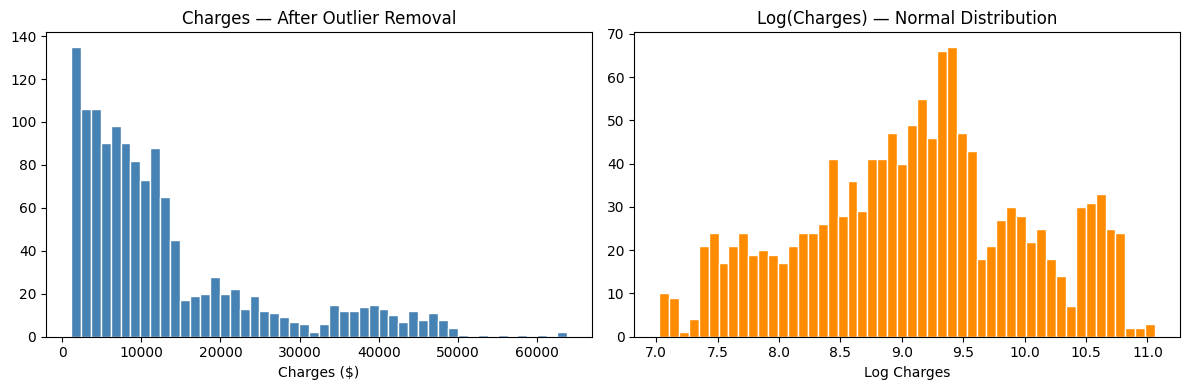


Original Skewness : 1.515
Log Skewness      : -0.090
→ Closer to 0 = More normal ✅


In [6]:
# STEP 5 — TARGET TRANSFORMATION (Log Transform)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Before
axes[0].hist(df['charges'], bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('Charges — After Outlier Removal')
axes[0].set_xlabel('Charges ($)')
 
# After log
df['log_charges'] = np.log(df['charges'])
 
axes[1].hist(df['log_charges'], bins=50,
             color='darkorange', edgecolor='white')
axes[1].set_title('Log(Charges) — Normal Distribution')
axes[1].set_xlabel('Log Charges')
 
plt.tight_layout()
plt.savefig('charges_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
 
print(f"\nOriginal Skewness : {df['charges'].skew():.3f}")
print(f"Log Skewness      : {df['log_charges'].skew():.3f}")
print("→ Closer to 0 = More normal ✅")

In [7]:
# STEP 6 — FEATURES & TARGET SPLIT

FEATURES = [
    'age',          # Strong predictor (0.534 correlation)
    'bmi',          # Useful with smoker combo
    'children',     # Weak but present (0.133)
    'smoker',       # Dominant predictor (0.832)
    'bmi_smoker',   # Obese + Smoker combo
    'obese',        # BMI > 30 flag
    'age_smoker',   # Old + Smoker = Extreme risk (NEW)
    'age_bmi'       # Old + Obese = High risk (NEW)
]
 
X = df[FEATURES]
y = df['log_charges']
 
print("\nFinal Features:", FEATURES)
print("X shape:", X.shape)
 
# 80/20 split — stratify not needed for regression
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
 
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
 
 
# STEP 7 — FEATURE SCALING
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
 
print("\nScaling done ✅")


Final Features: ['age', 'bmi', 'children', 'smoker', 'bmi_smoker', 'obese', 'age_smoker', 'age_bmi']
X shape: (1337, 8)
Train: (1069, 8) | Test: (268, 8)

Scaling done ✅


In [8]:
# STEP 8 — TRAIN 3 MODELS 
models = {
    "Linear Regression"  : LinearRegression(),
    "Random Forest"      : RandomForestRegressor(
                               n_estimators=100,
                               random_state=42
                           ),
    "Gradient Boosting"  : GradientBoostingRegressor(
                               n_estimators=100,
                               learning_rate=0.1,
                               random_state=42
                           )
}
 
results = {}
 
print("\n" + "=" * 55)
print("MODEL RESULTS")
print("=" * 55)
 
for name, model in models.items():
 
    # Train
    model.fit(X_train_scaled, y_train)
 
    # Predict on log scale
    y_pred_log = model.predict(X_test_scaled)
 
    # Convert back to dollar scale
    y_pred_actual = np.exp(y_pred_log)
    y_test_actual = np.exp(y_test)
 
    r2   = r2_score(y_test_actual, y_pred_actual)
    mae  = mean_absolute_error(y_test_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
 
    results[name] = {
        'model'       : model,
        'r2'          : r2,
        'mae'         : mae,
        'rmse'        : rmse,
        'predictions' : y_pred_actual
    }
 
    print(f"\n📌 {name}")
    print(f"   R² Score : {r2:.4f}  ({r2*100:.1f}% variance explained)")
    print(f"   MAE      : ${mae:,.0f}  (average dollar error)")
    print(f"   RMSE     : ${rmse:,.0f}  (outlier-sensitive error)")


MODEL RESULTS

📌 Linear Regression
   R² Score : 0.8433  (84.3% variance explained)
   MAE      : $2,844  (average dollar error)
   RMSE     : $5,365  (outlier-sensitive error)

📌 Random Forest
   R² Score : 0.8896  (89.0% variance explained)
   MAE      : $2,235  (average dollar error)
   RMSE     : $4,504  (outlier-sensitive error)

📌 Gradient Boosting
   R² Score : 0.8877  (88.8% variance explained)
   MAE      : $2,091  (average dollar error)
   RMSE     : $4,544  (outlier-sensitive error)



✅ Best Model: Random Forest
   R² Score : 0.8896
   MAE      : $2,235
   RMSE     : $4,504


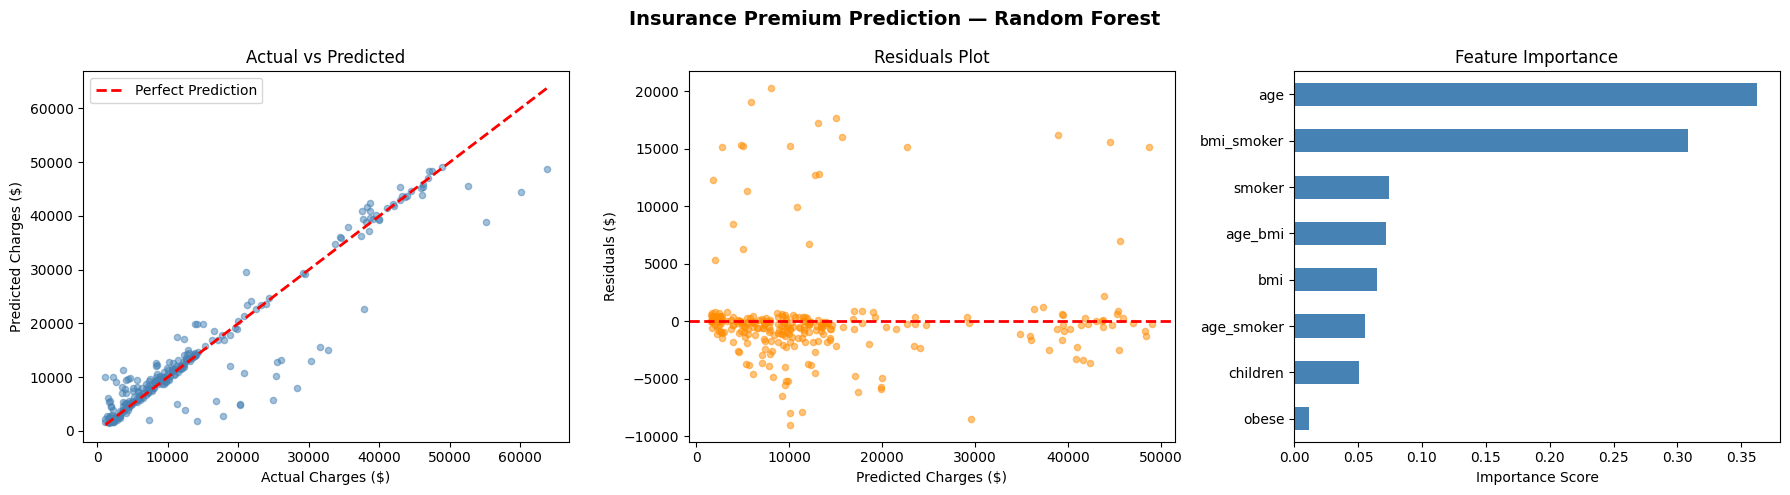


Plot saved → insurance_results.png ✅


In [9]:

# STEP 9 — SELECT BEST MODEL (by R² Score)
 
best_name  = max(results, key=lambda x: results[x]['r2'])
best       = results[best_name]
 
print("\n" + "=" * 55)
print(f"✅ Best Model: {best_name}")
print(f"   R² Score : {best['r2']:.4f}")
print(f"   MAE      : ${best['mae']:,.0f}")
print(f"   RMSE     : ${best['rmse']:,.0f}")
print("=" * 55)
 
 
# STEP 10 — VISUALIZATIONS
 
y_test_actual = np.exp(y_test)
y_pred_best   = best['predictions']
 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Insurance Premium Prediction — {best_name}',
             fontsize=14, fontweight='bold')
 
# ── Plot 1: Actual vs Predicted ──────────────────────────
axes[0].scatter(y_test_actual, y_pred_best,
                alpha=0.5, color='steelblue', s=20)
axes[0].plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Charges ($)')
axes[0].set_ylabel('Predicted Charges ($)')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()
 
# ── Plot 2: Residuals Plot ───────────────────────────────
residuals = y_test_actual - y_pred_best
axes[1].scatter(y_pred_best, residuals,
                alpha=0.5, color='darkorange', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Charges ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residuals Plot')
 
# ── Plot 3: Feature Importance ───────────────────────────
if best_name in ["Random Forest", "Gradient Boosting"]:
    feat_imp = pd.Series(
        best['model'].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)
 
    feat_imp.plot(kind='barh', ax=axes[2], color='steelblue')
    axes[2].set_title('Feature Importance')
    axes[2].set_xlabel('Importance Score')
else:
    # Linear Regression — show coefficients
    coef = pd.Series(
        np.abs(best['model'].coef_),
        index=FEATURES
    ).sort_values(ascending=True)
 
    coef.plot(kind='barh', ax=axes[2], color='steelblue')
    axes[2].set_title('Feature Coefficients (abs)')
    axes[2].set_xlabel('Coefficient Value')
 
plt.tight_layout()
plt.savefig('insurance_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved → insurance_results.png ✅")

In [10]:
# STEP 11 — MODEL COMPARISON TABLE 
print("\n" + "=" * 55)
print("FINAL MODEL COMPARISON")
print("=" * 55)
print(f"{'Model':<25} {'R²':>8} {'MAE':>12} {'RMSE':>12}")
print("-" * 55)
 
for name, res in results.items():
    marker = " ✅" if name == best_name else ""
    print(f"{name:<25} {res['r2']:>8.4f} "
          f"${res['mae']:>10,.0f} "
          f"${res['rmse']:>10,.0f}{marker}")


FINAL MODEL COMPARISON
Model                           R²          MAE         RMSE
-------------------------------------------------------
Linear Regression           0.8433 $     2,844 $     5,365
Random Forest               0.8896 $     2,235 $     4,504 ✅
Gradient Boosting           0.8877 $     2,091 $     4,544


In [11]:

# STEP 12 — SAMPLE PREDICTIONS
# 3 hypothetical customers 
 
print("\n" + "=" * 55)
print("SAMPLE PREDICTIONS")
print("=" * 55)
 
sample_customers = pd.DataFrame({
    'age'        : [25,   45,   60  ],
    'bmi'        : [22,   35,   40  ],
    'children'   : [0,    2,    3   ],
    'smoker'     : [0,    0,    1   ],
    'bmi_smoker' : [0,    0,    40  ],   # bmi × smoker
    'obese'      : [0,    1,    1   ],   # bmi > 30
    'age_smoker' : [0,    0,    60  ],   # age × smoker
    'age_bmi'    : [550,  1575, 2400],   # age × bmi
})
 
descriptions = [
    "Young (25), Healthy BMI, Non-Smoker",
    "Middle-aged (45), Obese, Non-Smoker",
    "Senior (60), Obese, Smoker"
]
 
sample_scaled = scaler.transform(sample_customers)
sample_pred   = np.exp(best['model'].predict(sample_scaled))
 
for i, (desc, pred) in enumerate(zip(descriptions, sample_pred)):
    print(f"\nCustomer {i+1}: {desc}")
    print(f"  Predicted Premium : ${pred:,.0f}/year")
    print(f"  Per Month         : ${pred/12:,.0f}/month")


SAMPLE PREDICTIONS

Customer 1: Young (25), Healthy BMI, Non-Smoker
  Predicted Premium : $3,895/year
  Per Month         : $325/month

Customer 2: Middle-aged (45), Obese, Non-Smoker
  Predicted Premium : $8,606/year
  Per Month         : $717/month

Customer 3: Senior (60), Obese, Smoker
  Predicted Premium : $48,465/year
  Per Month         : $4,039/month


In [12]:
# STEP 13 — BUSINESS INSIGHTS
 
print("\n" + "=" * 55)
print("BUSINESS INSIGHTS")
print("=" * 55)
 
# Smoker vs Non-Smoker
smoker_avg    = df[df['smoker'] == 1]['charges'].mean()
nonsmoker_avg = df[df['smoker'] == 0]['charges'].mean()
print(f"\nSmoker avg charges     : ${smoker_avg:,.0f}/year")
print(f"Non-Smoker avg charges : ${nonsmoker_avg:,.0f}/year")
print(f"Smokers pay {smoker_avg/nonsmoker_avg:.1f}x MORE!")
 
# Obese vs Normal
obese_avg  = df[df['obese'] == 1]['charges'].mean()
normal_avg = df[df['obese'] == 0]['charges'].mean()
print(f"\nObese avg charges      : ${obese_avg:,.0f}/year")
print(f"Normal BMI avg charges : ${normal_avg:,.0f}/year")
print(f"Obese people pay {obese_avg/normal_avg:.1f}x MORE!")
 
# Feature importance ranking
if hasattr(best['model'], 'feature_importances_'):
    feat_imp = pd.Series(
        best['model'].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=False)
 
    print(f"\nTop Charge Drivers ({best_name}):")
    for feat, imp in feat_imp.items():
        bar = '█' * int(imp * 100)
        print(f"  {feat:<15}: {bar} {imp:.4f}")


BUSINESS INSIGHTS

Smoker avg charges     : $32,050/year
Non-Smoker avg charges : $8,441/year
Smokers pay 3.8x MORE!

Obese avg charges      : $15,581/year
Normal BMI avg charges : $10,719/year
Obese people pay 1.5x MORE!

Top Charge Drivers (Random Forest):
  age            : ████████████████████████████████████ 0.3622
  bmi_smoker     : ██████████████████████████████ 0.3084
  smoker         : ███████ 0.0740
  age_bmi        : ███████ 0.0720
  bmi            : ██████ 0.0650
  age_smoker     : █████ 0.0554
  children       : █████ 0.0511
  obese          : █ 0.0119


In [13]:
# STEP 14 — SAVE MODEL & SCALER 
joblib.dump(best['model'], 'insurance_best_model.pkl')
joblib.dump(scaler,        'insurance_scaler.pkl')
 
print("\n" + "=" * 55)
print("Files Saved:")
print("  insurance_best_model.pkl ✅")
print("  insurance_scaler.pkl     ✅")
print("  insurance_results.png    ✅")
print("  charges_distribution.png ✅")
print("=" * 55)


Files Saved:
  insurance_best_model.pkl ✅
  insurance_scaler.pkl     ✅
  insurance_results.png    ✅
  charges_distribution.png ✅
